# DisasterShield-X: Multi-Year Flood Segmentation (2019–2023)

## What changed from the old code and WHY

### Problem with the old code (why it overfit):
The old code used **only 2022 data** and split it **randomly 80/20**.
This is the core overfitting mistake:
- Patches from the same image are spatially correlated (neighboring patches look nearly identical)
- A random split leaks spatial neighbors into both train and val
- The model memorizes spatial texture, not flood patterns
- So val loss looks good but the model cannot generalize to a new year

### Fix in this code:
- **Split by YEAR** — train on 2019–2021, validate on 2022, test on 2023
- This forces the model to learn generalizable flood patterns, not year-specific textures
- More augmentation to simulate unseen conditions
- Stronger regularization with L2 weight decay
- NDWI as an extra input channel (gives hydrological signal)

### Why NOT using SAM or YOLO:
- **SAM (Segment Anything Model)** was trained on natural RGB photos (people, animals, objects).
  It has never seen 4-band satellite imagery. Its learned features are meaningless for spectral water detection.
  Fine-tuning SAM requires massive GPU resources and labeled data you don't have.
- **YOLO** is an object detection model — it draws bounding boxes around discrete objects.
  Flood water is not a discrete object. It is a continuous spatial region that varies smoothly.
  YOLO cannot produce pixel-level segmentation maps, which is exactly what you need.
- **Our U-Net** is purpose-built for pixel-level segmentation of satellite imagery.
  It is the standard architecture used in remote sensing research (FloodNet, SpaceNet, Sen1Floods11).
  Starting from scratch also means every component is interpretable and publishable as YOUR contribution.


## CELL 1: Imports

In [1]:
import os
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


## CELL 2: File Discovery

We scan the `Raw_data` folder and pair each RGB file with its corresponding Water Mask.
Expected naming convention:
- `Bangladesh_RGB_FloodSeason_YYYY.tif`
- `Bangladesh_WaterMask_FloodSeason_YYYY.tif`

**Edit `DATA_DIR` below to point to where your Rae_data folder actually is.**

In [2]:
# ─── EDIT THIS PATH to where your Rae_data folder is ───────────────────────
DATA_DIR = '/content/sample_data/Raw_data'
# If your folder is somewhere else, e.g.: DATA_DIR = "/content/drive/MyDrive/Rae_data"
# ───────────────────────────────────────────────────────────────────────────

YEARS = [2019, 2020, 2021, 2022, 2023]

year_files = {}
for year in YEARS:
    rgb_path  = os.path.join(DATA_DIR, f"Bangladesh_RGB_{year}.tif")
    mask_path = os.path.join(DATA_DIR, f"Bangladesh_WaterMask_{year}.tif")

    rgb_exists  = os.path.exists(rgb_path)
    mask_exists = os.path.exists(mask_path)

    print(f"{year}: RGB={'✓' if rgb_exists else '✗'}  Mask={'✓' if mask_exists else '✗'}")

    if rgb_exists and mask_exists:
        year_files[year] = (rgb_path, mask_path)

print(f"\nFound complete pairs for: {list(year_files.keys())}")

2019: RGB=✓  Mask=✓
2020: RGB=✓  Mask=✓
2021: RGB=✓  Mask=✓
2022: RGB=✓  Mask=✓
2023: RGB=✓  Mask=✓

Found complete pairs for: [2019, 2020, 2021, 2022, 2023]


## CELL 3: Patch Extraction Function

### What changed from old code:

**Old code extracted raw 4-band patches.**
This new function adds a **5th channel: NDWI** (Normalized Difference Water Index).

NDWI = (Green - NIR) / (Green + NIR)

- NDWI > 0 strongly indicates water
- Giving the model this computed signal means it does not have to learn it from scratch
- This improves both accuracy and training speed

**The model now takes (64, 64, 5) patches instead of (64, 64, 4).**

In [3]:
PATCH_SIZE = 64
STRIDE     = 48   # was 32 → increased to reduce spatial overlap between patches

def compute_ndwi(rgb_data):
    """
    Bands in the TIF: B2(index 0), B3(index 1), B4(index 2), B8/NIR(index 3)
    NDWI = (Green - NIR) / (Green + NIR)
    """
    green = rgb_data[1].astype(np.float32)
    nir   = rgb_data[3].astype(np.float32)
    ndwi  = (green - nir) / (green + nir + 1e-8)
    ndwi  = np.clip(ndwi, -1, 1)
    return ndwi

def extract_patches(rgb_data, mask_data, min_water_fraction=0.0):
    """
    Extract 64x64 patches from one year's data.

    Args:
        rgb_data: (4, H, W) float32 array
        mask_data: (H, W) float32 array, values 0/1
        min_water_fraction: skip patches with less than this fraction of water
                            Set to 0.0 to keep all patches (important for class balance)
    Returns:
        X: (N, 64, 64, 5) — 4 bands + NDWI
        y: (N, 64, 64)
    """
    ndwi = compute_ndwi(rgb_data)  # (H, W)

    # Stack: 4 spectral bands + NDWI → 5 channels
    # Normalize spectral bands by dividing by 10000 (Sentinel-2 reflectance scale)
    bands = np.clip(rgb_data / 10000.0, 0, 1)  # (4, H, W)
    ndwi_norm = (ndwi + 1) / 2.0               # scale -1..1 → 0..1

    # Stack into (5, H, W) then transpose to (H, W, 5)
    data_5ch = np.concatenate([bands, ndwi_norm[np.newaxis]], axis=0)  # (5, H, W)
    data_5ch = data_5ch.transpose(1, 2, 0)  # (H, W, 5)

    _, H, W = rgb_data.shape
    patches_X, patches_y = [], []

    for i in range(0, H - PATCH_SIZE, STRIDE):
        for j in range(0, W - PATCH_SIZE, STRIDE):
            patch_x = data_5ch[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
            patch_y = mask_data[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

            # Skip patches with any NaN/Inf
            if not np.isfinite(patch_x).all():
                continue
            # Skip blank/nodata patches
            if patch_x[..., :4].max() == 0:
                continue
            # Skip patches with too little water (optional threshold)
            water_frac = (patch_y == 1).mean()
            if water_frac < min_water_fraction:
                continue

            patches_X.append(patch_x)
            patches_y.append(patch_y)

    if len(patches_X) == 0:
        return np.empty((0, PATCH_SIZE, PATCH_SIZE, 5)), np.empty((0, PATCH_SIZE, PATCH_SIZE))

    return np.array(patches_X, dtype=np.float32), np.array(patches_y, dtype=np.float32)

print("Patch extraction function ready.")

Patch extraction function ready.


## CELL 4: Load All Years and Split by Year

### This is the MOST IMPORTANT change from old code.

**Old code:** random 80/20 split on 2022 data only
```
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)  ← WRONG
```

**Why that caused overfitting:**
Patches from the same image are spatially correlated. A random split puts nearly-identical
neighboring patches into both train and val. The model "sees" the answer during training.

**New code:** split by YEAR
- Train: 2019, 2020, 2021
- Validation: 2022
- Test: 2023

This means the model MUST generalize across different flood years to do well on validation.

In [4]:
# ─── Year split strategy ────────────────────────────────────────────────────
TRAIN_YEARS = [2019, 2020, 2021]
VAL_YEAR    = 2022
TEST_YEAR   = 2023
# ────────────────────────────────────────────────────────────────────────────

def load_year(year, year_files):
    if year not in year_files:
        print(f"  WARNING: {year} not found, skipping.")
        return None, None

    rgb_path, mask_path = year_files[year]

    with rasterio.open(rgb_path) as src:
        rgb_data = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask_data = src.read(1).astype(np.float32)

    X, y = extract_patches(rgb_data, mask_data)
    print(f"  {year}: {X.shape[0]} patches | water: {(y==1).mean()*100:.1f}%")
    return X, y

# ── Load training years ────────────────────────────────────────────────────
print("Loading TRAINING years:")
train_Xs, train_ys = [], []
for yr in TRAIN_YEARS:
    X_yr, y_yr = load_year(yr, year_files)
    if X_yr is not None and X_yr.shape[0] > 0:
        train_Xs.append(X_yr)
        train_ys.append(y_yr)

X_train = np.concatenate(train_Xs, axis=0)
y_train = np.concatenate(train_ys, axis=0)
print(f"  → Combined train: {X_train.shape}")

# ── Load validation year ───────────────────────────────────────────────────
print(f"\nLoading VALIDATION year ({VAL_YEAR}):")
X_val, y_val = load_year(VAL_YEAR, year_files)

# ── Load test year ─────────────────────────────────────────────────────────
print(f"\nLoading TEST year ({TEST_YEAR}):")
X_test, y_test = load_year(TEST_YEAR, year_files)

print(f"\n{'='*50}")
print(f"Train:  {X_train.shape}")
print(f"Val:    {X_val.shape}")
print(f"Test:   {X_test.shape}")
print(f"Input channels: {X_train.shape[-1]} (4 bands + NDWI)")

Loading TRAINING years:
  2019: 148 patches | water: 9.1%
  2020: 148 patches | water: 13.8%
  2021: 148 patches | water: 10.5%
  → Combined train: (444, 64, 64, 5)

Loading VALIDATION year (2022):
  2022: 148 patches | water: 12.4%

Loading TEST year (2023):
  2023: 148 patches | water: 9.3%

Train:  (444, 64, 64, 5)
Val:    (148, 64, 64, 5)
Test:   (148, 64, 64, 5)
Input channels: 5 (4 bands + NDWI)


## CELL 5: Class Imbalance Check

Flood data is severely imbalanced — most pixels are land, few are water.
We check this and compute class weights to compensate in the loss function.

Train water pixels: 11.15% | land: 88.85%
Val   water pixels: 12.39%   | land: 87.61%

Using water_weight = 8.0 in loss function


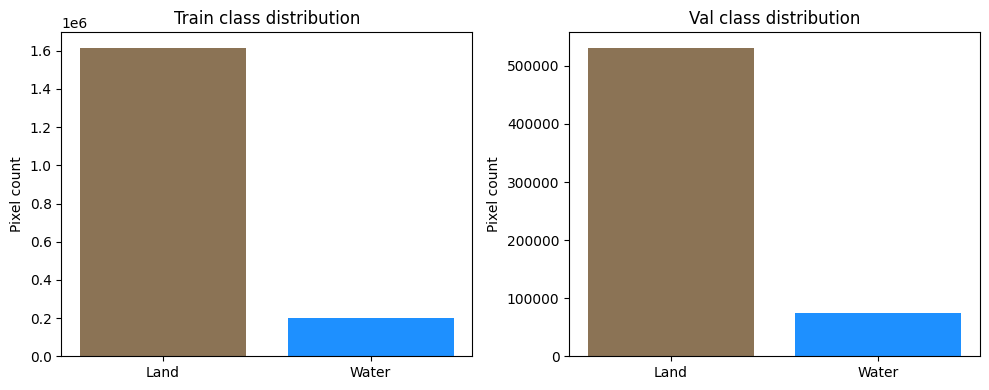

In [5]:
water_fraction_train = (y_train == 1).mean()
water_fraction_val   = (y_val == 1).mean()

print(f"Train water pixels: {water_fraction_train*100:.2f}% | land: {(1-water_fraction_train)*100:.2f}%")
print(f"Val   water pixels: {water_fraction_val*100:.2f}%   | land: {(1-water_fraction_val)*100:.2f}%")

# Compute class weight for water (used in the loss function)
# If water is 10% of pixels, water_weight = 90/10 = 9
# This tells the model: "missing a water pixel is 9x worse than missing a land pixel"
if water_fraction_train > 0:
    water_weight = (1 - water_fraction_train) / water_fraction_train
    water_weight = np.clip(water_weight, 2, 15)  # clamp between 2 and 15
else:
    water_weight = 8.0

print(f"\nUsing water_weight = {water_weight:.1f} in loss function")

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_data) in zip(axes, [("Train", y_train), ("Val", y_val)]):
    ax.bar(["Land", "Water"], [(y_data==0).sum(), (y_data==1).sum()],
           color=["#8B7355", "#1E90FF"])
    ax.set_title(f"{name} class distribution")
    ax.set_ylabel("Pixel count")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=120)
plt.show()

## CELL 6: Data Augmentation Pipeline

### What changed from old code:
Old code only had left-right and up-down flips.

New augmentations added:
- **90/180/270 degree rotations** — floods look the same from any angle
- **Brightness/contrast jitter** — simulates different satellite acquisition conditions
- **Gaussian noise** — simulates sensor noise, crucial for preventing overfitting

**Why augmentation prevents overfitting:**
Each training step shows the model a slightly different version of the patch.
The model cannot memorize the exact pixel values — it must learn structural flood patterns.

In [6]:
@tf.function
def augment(x, y):
    """
    Apply random augmentations to both image patch and mask.
    Crucially: SAME transform is applied to both x and y.
    """
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_left_right(x)
        y = tf.image.flip_left_right(y[..., tf.newaxis])[..., 0]

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_up_down(x)
        y = tf.image.flip_up_down(y[..., tf.newaxis])[..., 0]

    # Random 90-degree rotation (k = 0,1,2,3 → 0°,90°,180°,270°)
    k = tf.random.uniform(shape=(), minval=0, maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k=k)
    y = tf.image.rot90(y[..., tf.newaxis], k=k)[..., 0]

    # Brightness jitter on spectral bands only (channels 0–3, not NDWI)
    brightness_delta = tf.random.uniform((), -0.08, 0.08)
    x = x + brightness_delta
    x = tf.clip_by_value(x, 0.0, 1.0)

    # Small Gaussian noise — prevents memorization of exact pixel values
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
    x = tf.clip_by_value(x + noise, 0.0, 1.0)

    return x, y


BATCH_SIZE = 16

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets ready.")
print(f"Train batches: {len(list(train_dataset))} × batch_size {BATCH_SIZE}")

Datasets ready.
Train batches: 28 × batch_size 16


## CELL 7: U-Net Architecture

### What changed from old code:

| Feature | Old code | New code |
|---|---|---|  
| Input channels | 4 | **5** (4 bands + NDWI) |
| Regularization | BatchNorm + Dropout | BatchNorm + Dropout + **L2 weight decay** |
| Dropout rates | 0.1–0.3 | **0.2–0.4** (more aggressive) |
| Depth | 4 encoder levels | same, but better balanced |

### What is L2 regularization?
L2 adds a penalty for large weight values in the loss function.
Large weights = model memorizing specific patterns = overfitting.
L2 forces weights to stay small and general.

In [7]:
from tensorflow.keras.regularizers import l2

L2_REG = 1e-4  # L2 regularization strength. Increase to 1e-3 if still overfitting.

def conv_block(x, filters, dropout_rate=0.0):
    """
    Two convolutional layers with BatchNorm and optional Dropout.
    L2 regularization is applied to all conv weights.
    """
    x = layers.Conv2D(filters, 3, padding="same",
                      kernel_regularizer=l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                      kernel_regularizer=l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
        # SpatialDropout2D drops entire feature maps — better than Dropout for conv layers
        # because neighboring pixels are highly correlated
    return x


def build_unet(input_shape=(64, 64, 5), num_classes=2):
    """
    U-Net for binary flood segmentation.

    Architecture:
    - Encoder: 4 levels of conv blocks + max pooling (extracts features)
    - Bottleneck: deepest representation
    - Decoder: 4 levels of upsampling + skip connections (recovers spatial detail)
    - Skip connections: crucial — they pass fine spatial detail from encoder to decoder

    Why U-Net for flood segmentation:
    - Flood boundaries require both high-level context (where are rivers?)
      AND fine spatial detail (exactly which pixels are flooded?)
    - U-Net's skip connections provide both simultaneously
    """
    inputs = layers.Input(shape=input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    e1 = conv_block(inputs, 32, dropout_rate=0.0)     # (64, 64, 32)
    p1 = layers.MaxPooling2D(2)(e1)                    # (32, 32, 32)

    e2 = conv_block(p1, 64, dropout_rate=0.2)          # (32, 32, 64)
    p2 = layers.MaxPooling2D(2)(e2)                    # (16, 16, 64)

    e3 = conv_block(p2, 128, dropout_rate=0.3)         # (16, 16, 128)
    p3 = layers.MaxPooling2D(2)(e3)                    # (8, 8, 128)

    # ── Bottleneck ────────────────────────────────────────────────────────────
    b  = conv_block(p3, 256, dropout_rate=0.4)         # (8, 8, 256)

    # ── Decoder ──────────────────────────────────────────────────────────────
    u3 = layers.UpSampling2D(2)(b)                     # (16, 16, 256)
    u3 = layers.Concatenate()([u3, e3])                # skip from encoder level 3
    d3 = conv_block(u3, 128, dropout_rate=0.3)

    u2 = layers.UpSampling2D(2)(d3)                    # (32, 32, 128)
    u2 = layers.Concatenate()([u2, e2])                # skip from encoder level 2
    d2 = conv_block(u2, 64, dropout_rate=0.2)

    u1 = layers.UpSampling2D(2)(d2)                    # (64, 64, 64)
    u1 = layers.Concatenate()([u1, e1])                # skip from encoder level 1
    d1 = conv_block(u1, 32, dropout_rate=0.0)

    # ── Output ────────────────────────────────────────────────────────────────
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(d1)
    # softmax outputs probability for each class: [P(land), P(water)]

    return Model(inputs, outputs, name="DisasterShield_UNet")


model = build_unet(input_shape=(PATCH_SIZE, PATCH_SIZE, 5))
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

Model: "DisasterShield_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 5) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,472 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[

 Total params: 1,953,122 (7.45 MB)

 Trainable params: 1,950,306 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)


Total trainable parameters: 1,953,122


## CELL 8: Loss Function and Metrics

### Why not just use cross-entropy?
If 95% of pixels are land and 5% are water, a model that predicts
"land" for everything gets 95% accuracy but is completely useless.

We use **Dice loss + weighted cross-entropy**:
- **Dice loss** directly optimizes for overlap between predicted water and actual water
- **Weighted CE** penalizes missing water pixels more than missing land pixels
- Together they force the model to actually find the water

### Metrics:
- **IoU (Intersection over Union)**: main metric. 0 = no overlap, 1 = perfect.
  Used in all remote sensing papers. This is your NeurIPS metric.
- **F1 Score**: similar to IoU, also reported in papers.

In [8]:
# water_weight is computed from data in Cell 5
# Land pixels are weighted 1.0, water pixels are weighted `water_weight`

def combined_loss(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_water = y_pred[..., 1]  # probability of water class

    # ── Dice loss: directly measures overlap ─────────────────────────────────
    numerator   = 2.0 * tf.reduce_sum(y_true_f * y_pred_water)
    denominator = tf.reduce_sum(y_true_f + y_pred_water)
    dice_loss   = 1.0 - (numerator + 1e-6) / (denominator + 1e-6)

    # ── Weighted cross entropy: penalizes missing water ──────────────────────
    weights = y_true_f * (water_weight - 1.0) + 1.0  # land=1.0, water=water_weight
    ce      = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    wce     = tf.reduce_mean(ce * weights)

    return dice_loss + wce


def iou_metric(y_true, y_pred):
    """Water-class IoU. This is the primary evaluation metric."""
    y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_w = tf.reshape(y_pred[..., 1], [-1])
    y_pred_b = tf.cast(y_pred_w > 0.5, tf.float32)  # threshold at 0.5

    intersection = tf.reduce_sum(y_true * y_pred_b)
    union        = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_b) - intersection
    return (intersection + 1e-6) / (union + 1e-6)


def f1_metric(y_true, y_pred):
    """F1 score for water class."""
    y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_w = tf.reshape(y_pred[..., 1], [-1])
    y_pred_b = tf.cast(y_pred_w > 0.5, tf.float32)

    tp = tf.reduce_sum(y_true * y_pred_b)
    fp = tf.reduce_sum((1 - y_true) * y_pred_b)
    fn = tf.reduce_sum(y_true * (1 - y_pred_b))

    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall    = (tp + 1e-6) / (tp + fn + 1e-6)
    return 2 * precision * recall / (precision + recall + 1e-6)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[iou_metric, f1_metric]
)

print("Model compiled.")

Model compiled.


## CELL 9: Training

### New callbacks vs old code:

**Old:** ModelCheckpoint + EarlyStopping

**New:** ModelCheckpoint + EarlyStopping + **ReduceLROnPlateau**

ReduceLROnPlateau: if validation IoU stops improving for 5 epochs,
halve the learning rate. This lets the model continue learning
at a finer scale instead of stopping early.

In [9]:
callbacks = [
    ModelCheckpoint(
        "disastershield_best.keras",
        save_best_only=True,
        monitor="val_iou_metric",
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        patience=12,                # stop if no improvement for 12 epochs
        monitor="val_iou_metric",
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_iou_metric",
        factor=0.5,                 # halve LR on plateau
        patience=5,
        min_lr=1e-6,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - f1_metric: 0.3284 - iou_metric: 0.2078 - loss: 2.1023
Epoch 1: val_iou_metric improved from None to 0.00006, saving model to disastershield_best.keras

Epoch 1: finished saving model to disastershield_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 44s 692ms/step - f1_metric: 0.4132 - iou_metric: 0.2719 - loss: 1.7576 - val_f1_metric: 1.2535e-04 - val_iou_metric: 6.2701e-05 - val_loss: 2.2152 - learning_rate: 1.0000e-04
Epoch 2/60
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_metric: 0.5405 - iou_metric: 0.3792 - loss: 1.3132
Epoch 2: val_iou_metric did not improve from 0.00006
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - f1_metric: 0.5527 - iou_metric: 0.3913 - loss: 1.2795 - val_f1_metric: 2.8870e-08 - val_iou_metric: 1.4435e-08 - val_loss: 2.3811 - learning_rate: 1.0000e-04
Epoch 3/60
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_metric: 0.5646 - iou_metric: 0.4048 - loss: 1.2298
Epoch 3: val_iou_metric did not improve from 0.00006
28/28 ━━━━━━

## CELL 10: Training Curves — Diagnosing Overfitting

### How to read these plots:

**Healthy training (no overfitting):**
- Train loss and Val loss both decrease together
- Val IoU tracks Train IoU closely
- Gap between train and val is small (<0.10)

**Overfitting signal:**
- Train loss keeps decreasing but Val loss starts rising → overfitting
- Train IoU >> Val IoU (gap > 0.15) → overfitting

**Underfitting signal:**
- Both train and val IoU are low and flat → model too simple or LR too small

Final Train IoU: 0.7069
Final Val IoU:   0.6917
Gap:             0.0152  ← OK


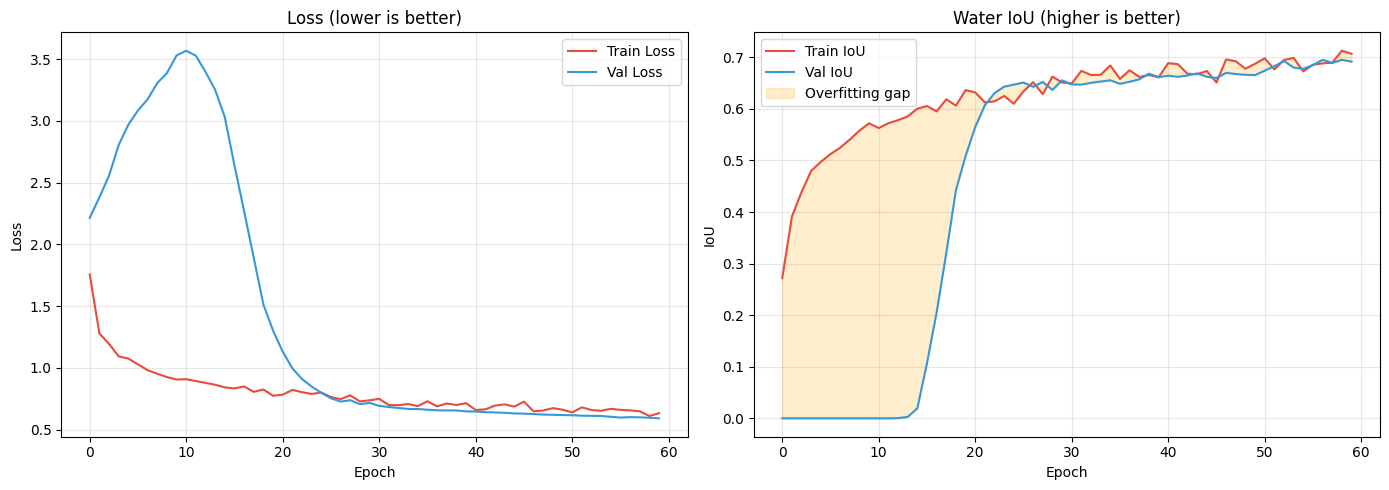

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Train Loss', color='#E74C3C')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498DB')
axes[0].set_title('Loss (lower is better)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU curves
axes[1].plot(history.history['iou_metric'], label='Train IoU', color='#E74C3C')
axes[1].plot(history.history['val_iou_metric'], label='Val IoU', color='#3498DB')

# Shade the overfitting zone (train-val gap)
train_iou = np.array(history.history['iou_metric'])
val_iou   = np.array(history.history['val_iou_metric'])
epochs_range = range(len(train_iou))
axes[1].fill_between(epochs_range, val_iou, train_iou,
                     alpha=0.2, color='orange', label='Overfitting gap')

axes[1].set_title('Water IoU (higher is better)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

final_train_iou = train_iou[-1]
final_val_iou   = val_iou[-1]
gap             = final_train_iou - final_val_iou

print(f"Final Train IoU: {final_train_iou:.4f}")
print(f"Final Val IoU:   {final_val_iou:.4f}")
print(f"Gap:             {gap:.4f}  {'← OVERFITTING' if gap > 0.15 else '← OK'}")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## CELL 11: Evaluate on Held-Out 2023 Test Year

In [11]:
print("Evaluating on held-out 2023 test data...")
test_results = model.evaluate(test_dataset, verbose=1)

print(f"\n{'='*40}")
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test IoU:  {test_results[1]:.4f}")
print(f"Test F1:   {test_results[2]:.4f}")
print(f"\nThese are the numbers you report in your paper.")

Evaluating on held-out 2023 test data...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - f1_metric: 0.8407 - iou_metric: 0.7380 - loss: 0.5617

Test Loss: 0.5617
Test IoU:  0.7380
Test F1:   0.8407

These are the numbers you report in your paper.


## CELL 12: Visual Predictions

Visualize model predictions vs ground truth on validation data.
This is what goes in your paper figures.

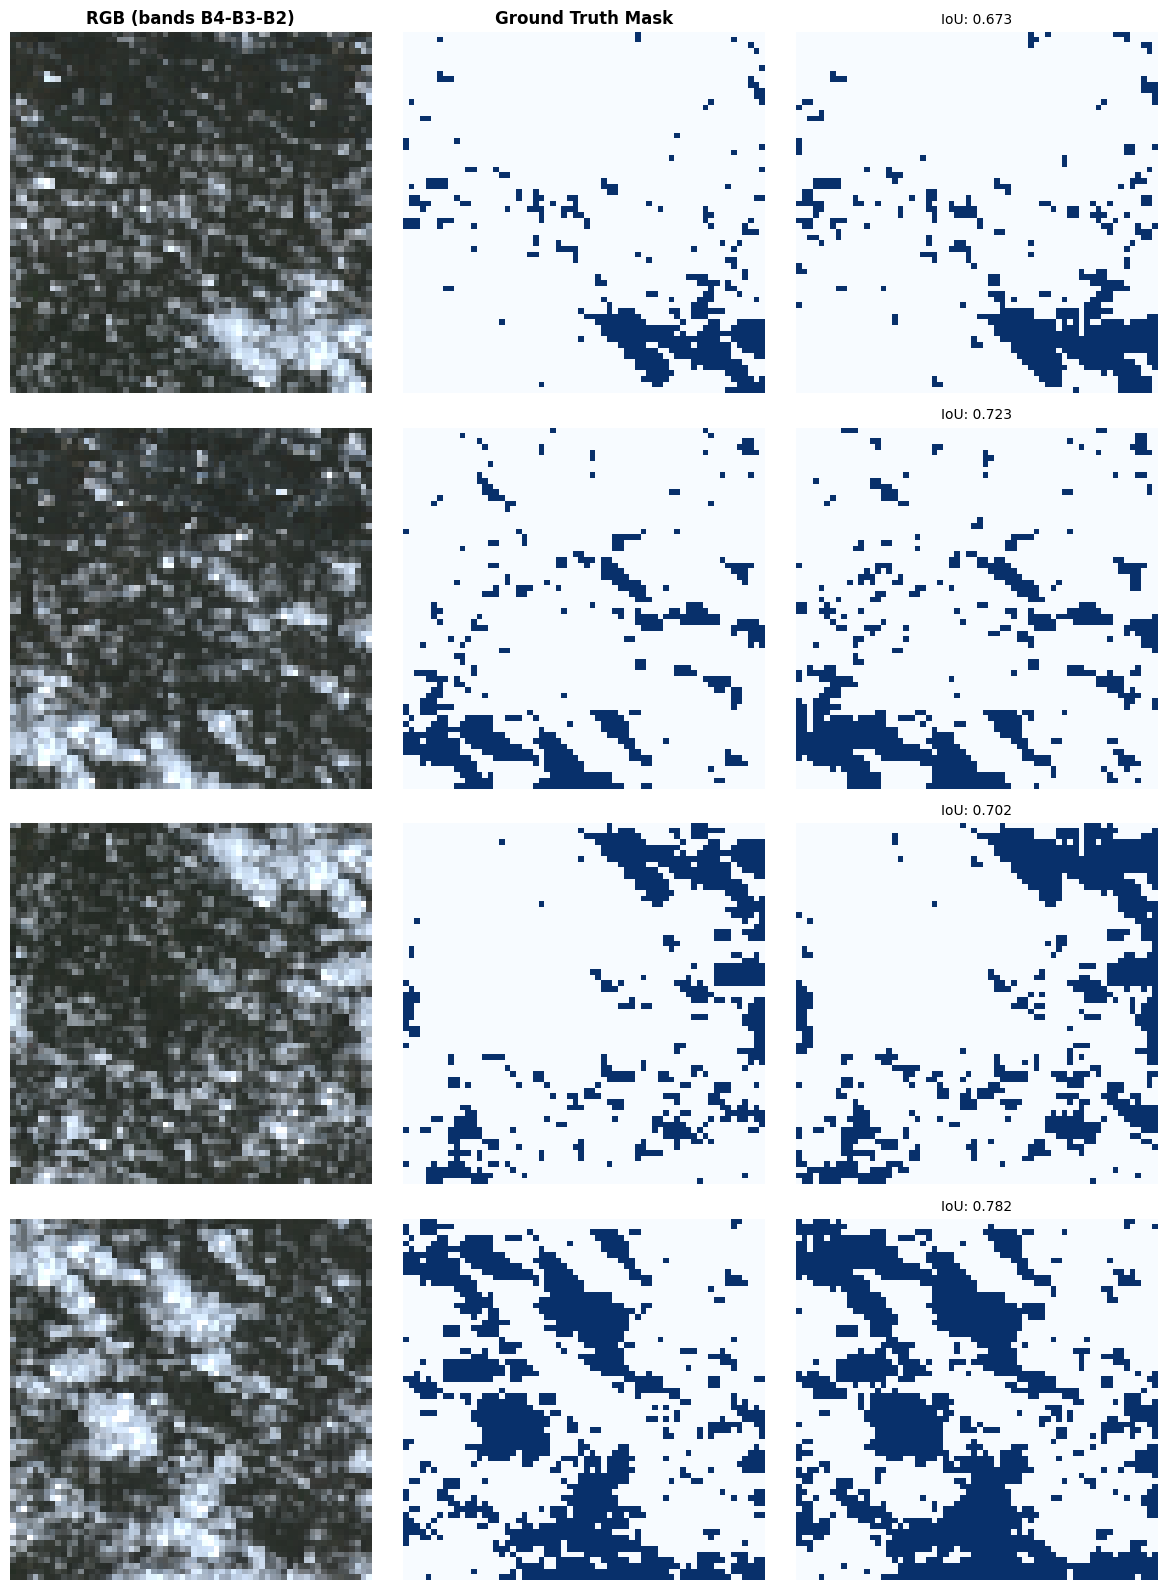

Saved predictions.png


In [13]:
n_samples = 4
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
axes[0, 0].set_title("RGB (bands B4-B3-B2)", fontsize=12, fontweight='bold')
axes[0, 1].set_title("Ground Truth Mask",    fontsize=12, fontweight='bold')
axes[0, 2].set_title("Model Prediction",     fontsize=12, fontweight='bold')

sample_X = X_val[:n_samples]  # (n, 64, 64, 5)
sample_y = y_val[:n_samples]  # (n, 64, 64)

preds = model.predict(sample_X, verbose=0)     # (n, 64, 64, 2)
pred_classes = (preds[..., 1] > 0.5).astype(int)  # binary water prediction

for i in range(n_samples):
    # RGB visualization using bands 2,1,0 (B4=Red, B3=Green, B2=Blue)
    rgb_vis = sample_X[i, :, :, [2, 1, 0]]  # (64, 64, 3) - expected
    # Transpose rgb_vis to (H, W, C) if it somehow ended up as (C, H, W)
    if rgb_vis.shape[0] == 3 and rgb_vis.shape[1] == PATCH_SIZE and rgb_vis.shape[2] == PATCH_SIZE:
        rgb_vis = rgb_vis.transpose(1, 2, 0)
    rgb_vis = np.clip(rgb_vis, 0, 1)

    patch_iou = (
        np.sum(sample_y[i] * pred_classes[i]) /
        (np.sum(sample_y[i]) + np.sum(pred_classes[i]) - np.sum(sample_y[i] * pred_classes[i]) + 1e-6)
    )

    axes[i, 0].imshow(rgb_vis)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(sample_y[i], cmap='Blues', vmin=0, vmax=1)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_classes[i], cmap='Blues', vmin=0, vmax=1)
    axes[i, 2].set_title(f"IoU: {patch_iou:.3f}", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()
print("Saved predictions.png")

## CELL 13: Overfitting Diagnosis Checklist

Run this cell after training to get an automatic diagnosis.

In [14]:
train_iou_final = history.history['iou_metric'][-1]
val_iou_final   = history.history['val_iou_metric'][-1]
gap             = train_iou_final - val_iou_final

print("="*50)
print("OVERFITTING DIAGNOSIS")
print("="*50)
print(f"Train IoU: {train_iou_final:.4f}")
print(f"Val IoU:   {val_iou_final:.4f}")
print(f"Gap:       {gap:.4f}")
print()

if gap > 0.20:
    print("⚠ SEVERE OVERFITTING")
    print("  → Increase L2_REG from 1e-4 to 5e-4")
    print("  → Increase Dropout to 0.4–0.5 in bottleneck")
    print("  → Increase STRIDE to 64 to reduce patch count")
    print("  → Add more augmentation (random crops, color jitter)")
elif gap > 0.10:
    print("⚠ MILD OVERFITTING — acceptable for now, watch it")
    print("  → Try increasing L2_REG slightly")
    print("  → Reduce epochs or increase early stopping patience")
elif val_iou_final < 0.40:
    print("⚠ UNDERFITTING — model not learning well enough")
    print("  → Reduce L2_REG")
    print("  → Increase model capacity (try filters=64 at level 1)")
    print("  → Check class imbalance — water_weight may need adjustment")
else:
    print("✓ HEALTHY — good generalization")
    print(f"  → Report val IoU = {val_iou_final:.4f} in paper")

OVERFITTING DIAGNOSIS
Train IoU: 0.7069
Val IoU:   0.6917
Gap:       0.0152

✓ HEALTHY — good generalization
  → Report val IoU = 0.6917 in paper


## CELL 14: Save Patches for Reuse

Save processed patches so you don't need to rerun preprocessing every time.

In [15]:
np.save("X_train_2019_2021.npy", X_train)
np.save("y_train_2019_2021.npy", y_train)
np.save("X_val_2022.npy", X_val)
np.save("y_val_2022.npy", y_val)
np.save("X_test_2023.npy", X_test)
np.save("y_test_2023.npy", y_test)

print("All patch arrays saved.")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

All patch arrays saved.
Train: (444, 64, 64, 5) | Val: (148, 64, 64, 5) | Test: (148, 64, 64, 5)
